# Ekstraksi Facial Landmarks MMEW (untuk Pre-training ST-GCN)

**Letak di peta:** notebook ini hidup di `stgcn/` dan menulis `stgcn_mmew_landmarks/`. Input: `../dataset/MMEW/Micro_Expression/`.

**Notasi tensor graf (ingat untuk sidang):** file disimpan `(T, V, C)` = waktu × titik × koordinat. Saat training, tensor di-permute menjadi `(C, T, V)`, lalu DataLoader menambah batch menjadi `(N, C, T, V)`.

Notebook ini mengubah setiap sekuens **mikro** MMEW menjadi tensor graf Face Mesh untuk ST-GCN.

Hanya partisi `MMEW/Micro_Expression/` yang diproses. Folder `Macro_Expression` diabaikan karena isinya still image 2D (tanpa sumbu waktu).

Pipeline:

1. Siapkan `stgcn_mmew_landmarks/{anger,disgust,fear,happiness,others,sadness,surprise}`
2. Indeks seluruh folder klip di `Micro_Expression/<emosi>/<Sxx-yy-zzz>/`
3. Uniform sampling `np.linspace` menjadi tepat **16 frame** per klip
4. Deteksi 468 landmark per frame dengan MediaPipe Face Mesh
5. Fallback jika wajah gagal terdeteksi (gambar sudah crop 231×231)
6. Simpan array `(16, 468, 3)` sebagai `{clip_id}.npy`
7. Sanity check: scatter plot 468 titik dari frame pertama

## Bentuk tensor akhir

| Dimensi | Nama | Arti |
|---------|------|------|
| `T = 16` | Time | frame hasil uniform sampling |
| `V = 468` | Vertices | node Face Mesh |
| `C = 3` | Channels | koordinat `(x, y, z)` |

> Tidak ada training di notebook ini. Hanya ekstraksi landmark.


In [1]:
# =============================================================================
# 1. IMPORT, PATH, DAN INISIALISASI FACE MESH
# =============================================================================
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

try:
    import mediapipe as mp
except ImportError as exc:
    raise ImportError(
        'Library mediapipe belum terpasang. Install dulu dengan:\n'
        '  pip install mediapipe'
    ) from exc

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Hanya Micro_Expression yang diekstrak — Macro_Expression diabaikan (still 2D).
DATASET_ROOT = Path('../dataset/MMEW').resolve()
MICRO_ROOT = DATASET_ROOT / 'Micro_Expression'
OUTPUT_ROOT = Path('stgcn_mmew_landmarks').resolve()  # stgcn/stgcn_mmew_landmarks

# T=16 wajib karena ST-GCN adalah Conv2d pada peta (T, V): panjang waktu harus identik tiap klip.
NUM_FRAMES = 16          # T — input wajib ST-GCN
# 468 = Face Mesh standar. refine_landmarks=True menambah iris jadi 478 dan merusak adjacency 468×468.
NUM_LANDMARKS = 468      # V — Face Mesh tanpa refine iris
NUM_CHANNELS = 3         # C — (x, y, z) ternormalisasi 0–1 oleh MediaPipe
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

if not MICRO_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder Micro_Expression tidak ditemukan: {MICRO_ROOT}\n'
        'Sesuaikan DATASET_ROOT dengan lokasi MMEW.'
    )

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,   # tiap JPG diproses mandiri; bukan tracking video berurutan
    max_num_faces=1,          # satu wajah per crop MMEW; lebih dari 1 hanya menambah noise
    refine_landmarks=False,   # kunci: tetap 468 node agar kompatibel dengan graf SMIC
)

print(f'Dataset mikro : {MICRO_ROOT}')
print(f'Output root   : {OUTPUT_ROOT}')
print(f'Bentuk tensor : (T={NUM_FRAMES}, V={NUM_LANDMARKS}, C={NUM_CHANNELS})')
print('Macro_Expression tidak diproses.')


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset mikro : /Users/stefanieagahari/Micro-Expression-Detector/python test/MMEW/Micro_Expression
Output root   : /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks
Bentuk tensor : (T=16, V=468, C=3)
Macro_Expression tidak diproses.


I0000 00:00:1788413121.339686 4044358 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


W0000 00:00:1788413121.342746 4044543 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2. Setup Direktori Output

Hierarki kelas emosi `Micro_Expression` dipertahankan:

```text
stgcn_mmew_landmarks/
├── anger/
├── disgust/
├── fear/
├── happiness/
├── others/
├── sadness/
└── surprise/
```

In [2]:
# =============================================================================
# 2. BUAT FOLDER KELUARAN — SPIEGEL HIERARKI KELAS MIKRO
# =============================================================================
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

emotion_classes = sorted(
    p.name for p in MICRO_ROOT.iterdir()
    if p.is_dir() and not p.name.startswith('.')
)

class_dirs = {}
for emotion in emotion_classes:
    class_dir = OUTPUT_ROOT / emotion
    class_dir.mkdir(parents=True, exist_ok=True)
    class_dirs[emotion] = class_dir
    print(f'Siap: {class_dir}')

print(f'\nFolder Landmark: {OUTPUT_ROOT}')
print(f'Kelas emosi    : {emotion_classes}')

Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/anger
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/disgust
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/fear
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/happiness
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/others
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/sadness
Siap: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/surprise

Folder Landmark: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks
Kelas emosi    : ['anger', 'disgust', 'fear', 'happiness', 'others', 'sadness', 'surprise']


## 3. Indeks Klip Mikro

Satu sampel = satu folder `Micro_Expression/<emosi>/<Sxx-yy-zzz>/` berisi urutan `1.jpg`, `2.jpg`, …

In [3]:
# =============================================================================
# 3. INDEKS SEMUA KLIP DI Micro_Expression
# =============================================================================
def frame_sort_key(path: Path):
    """Urutkan 1.jpg, 2.jpg, ... secara numerik (bukan leksikografis)."""
    return int(path.stem) if path.stem.isdigit() else 10**9


def list_clip_frames(clip_dir: str | Path) -> list[Path]:
    """Ambil seluruh frame gambar di dalam satu folder klip."""
    clip_dir = Path(clip_dir)
    frames = [
        path for path in clip_dir.iterdir()
        if path.is_file()
        and not path.name.startswith('.')
        and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    return sorted(frames, key=frame_sort_key)


def build_micro_index(micro_root: Path) -> pd.DataFrame:
    """Satu baris = satu folder sekuens mikro."""
    records = []
    for emotion_dir in sorted(p for p in micro_root.iterdir() if p.is_dir() and not p.name.startswith('.')):
        for clip_dir in sorted(p for p in emotion_dir.iterdir() if p.is_dir() and not p.name.startswith('.')):
            frames = list_clip_frames(clip_dir)
            if not frames:
                continue
            clip_id = clip_dir.name
            subject_id = clip_id.split('-')[0] if '-' in clip_id else None
            records.append({
                'clip_id': clip_id,
                'subject_id': subject_id,
                'emotion_label': emotion_dir.name,
                'clip_path': str(clip_dir.resolve()),
                'n_source_frames': len(frames),
            })
    return pd.DataFrame(records)


clip_df = build_micro_index(MICRO_ROOT)
print(f'Total klip mikro : {len(clip_df)}')
print('Distribusi kelas:')
print(clip_df['emotion_label'].value_counts().reindex(emotion_classes))
print(f"\nRata-rata frame sumber : {clip_df['n_source_frames'].mean():.2f}")
clip_df.head()

Total klip mikro : 300
Distribusi kelas:
emotion_label
anger         8
disgust      72
fear         16
happiness    36
others       66
sadness      13
surprise     89
Name: count, dtype: int64

Rata-rata frame sumber : 37.96


,clip_id,subject_id,emotion_label,clip_path,n_source_frames
0,S13-07-001,S13,anger,/Users/stefanieagahari/Micro-Expression-Detect...,44
1,S17-07-001,S17,anger,/Users/stefanieagahari/Micro-Expression-Detect...,32
2,S17-07-002,S17,anger,/Users/stefanieagahari/Micro-Expression-Detect...,39
3,S18-07-001,S18,anger,/Users/stefanieagahari/Micro-Expression-Detect...,43
4,S18-07-002,S18,anger,/Users/stefanieagahari/Micro-Expression-Detect...,34


## 4. Uniform Sampling (T = 16) + Fallback Landmark

Panjang klip MMEW bervariasi (rata-rata ~38 frame). `np.linspace` memilih 16 indeks merata dari frame pertama sampai terakhir.

**Fallback** (wajah crop 231×231 kadang gagal dideteksi MediaPipe):

- Gagal di tengah → salin koordinat frame sebelumnya
- Gagal di awal → setelah loop, *backfill* dengan deteksi valid terdekat (pertama yang sukses)
- Gagal di seluruh 16 frame → klip tidak disimpan
**Matematika sampling:** `np.linspace(0, L-1, 16)` memilih 16 titik merata pada sumbu frame. Ujung klip (onset dan offset) selalu ikut, sehingga gerak awal dan akhir tidak terbuang. Jika `L < 16`, beberapa indeks berulang — itu padding implisit, bukan error.


In [4]:
# =============================================================================
# 4. UNIFORM SAMPLING + EKSTRAKSI 468 LANDMARK PER KLIP
# =============================================================================
def uniform_sample_indices(num_available: int, num_target: int) -> np.ndarray:
    """Ambil num_target indeks merata sepanjang sequence.

    np.linspace menjamin ujung awal dan akhir klip ikut terwakili.
    Jika num_available < num_target, beberapa frame akan terulang.
    """
    if num_available <= 0:
        raise ValueError('Sequence tidak memiliki frame.')
    if num_available == 1:
        return np.zeros(num_target, dtype=int)

    # linspace menghasilkan float; round ke indeks integer terdekat lalu dikunci ke rentang valid.
    indices = np.linspace(0, num_available - 1, num=num_target)
    return np.clip(np.round(indices).astype(int), 0, num_available - 1)


def landmarks_to_array(face_landmarks) -> np.ndarray:
    """Ubah hasil Face Mesh menjadi array (468, 3) berisi (x, y, z)."""
    return np.array(
        [[lm.x, lm.y, lm.z] for lm in face_landmarks.landmark],
        dtype=np.float32,
    )[:NUM_LANDMARKS]


def extract_clip_landmarks(clip_folder_path: str | Path) -> dict:
    """Ekstrak tensor (T=16, V=468, C=3) dari satu folder klip MMEW."""
    clip_dir = Path(clip_folder_path)
    frame_paths = list_clip_frames(clip_dir)
    if not frame_paths:
        raise FileNotFoundError(f'Tidak ada frame gambar di {clip_dir}')

    sampled_idx = uniform_sample_indices(len(frame_paths), NUM_FRAMES)
    sampled_paths = [frame_paths[i] for i in sampled_idx]

    clip_landmarks = np.zeros(
        (NUM_FRAMES, NUM_LANDMARKS, NUM_CHANNELS), dtype=np.float32
    )

    last_valid = None
    first_valid_position = None
    n_detected = 0

    for position, frame_path in enumerate(sampled_paths):
        image_bgr = cv2.imread(str(frame_path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            raise IOError(f'Gagal membaca frame: {frame_path}')

        # MediaPipe hanya menerima RGB. Memberi BGR membuat deteksi wajah gagal diam-diam.
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        result = face_mesh.process(image_rgb)

        if result.multi_face_landmarks:
            coords = landmarks_to_array(result.multi_face_landmarks[0])
            clip_landmarks[position] = coords
            last_valid = coords
            n_detected += 1
            if first_valid_position is None:
                first_valid_position = position
        elif last_valid is not None:
            # FALLBACK: salin koordinat frame sebelumnya
            clip_landmarks[position] = last_valid

    if first_valid_position is None:
        return {'landmarks': None, 'n_detected': 0, 'n_fallback': NUM_FRAMES}

    # Frame awal yang gagal diisi deteksi valid terdekat (pertama yang sukses)
    if first_valid_position > 0:
        clip_landmarks[:first_valid_position] = clip_landmarks[first_valid_position]

    return {
        'landmarks': clip_landmarks,
        'n_detected': n_detected,
        'n_fallback': NUM_FRAMES - n_detected,
    }


## 5. Eksekusi Batch

Setiap klip valid disimpan ke `stgcn_mmew_landmarks/{kelas}/{clip_id}.npy`.
Klip yang gagal **tidak disimpan**. Melatih ST-GCN pada tensor nol akan mengajarkan pola palsu (semua node di origin).


In [5]:
# =============================================================================
# 5. LOOP EKSTRAKSI SELURUH KLIP MIKRO
# =============================================================================
landmark_records = []
n_success = 0
n_failed = 0

for row in tqdm(clip_df.itertuples(index=False), total=len(clip_df), desc='Landmark MMEW'):
    out_path = class_dirs[row.emotion_label] / f'{row.clip_id}.npy'
    try:
        result = extract_clip_landmarks(row.clip_path)
    except Exception as exc:
        landmark_records.append({
            'clip_id': row.clip_id,
            'subject_id': row.subject_id,
            'emotion_label': row.emotion_label,
            'n_source_frames': row.n_source_frames,
            'landmark_path': None,
            'n_detected': 0,
            'n_fallback': NUM_FRAMES,
            'status': f'error: {exc}',
        })
        n_failed += 1
        continue

    if result['landmarks'] is None:
        landmark_records.append({
            'clip_id': row.clip_id,
            'subject_id': row.subject_id,
            'emotion_label': row.emotion_label,
            'n_source_frames': row.n_source_frames,
            'landmark_path': None,
            'n_detected': 0,
            'n_fallback': NUM_FRAMES,
            'status': 'no_face',
        })
        n_failed += 1
        continue

    # float32 (16,468,3). Nama file = clip_id agar pre-training bisa menelusuri sampel bermasalah.
    np.save(out_path, result['landmarks'])
    landmark_records.append({
        'clip_id': row.clip_id,
        'subject_id': row.subject_id,
        'emotion_label': row.emotion_label,
        'n_source_frames': row.n_source_frames,
        'landmark_path': str(out_path),
        'n_detected': result['n_detected'],
        'n_fallback': result['n_fallback'],
        'status': 'ok',
    })
    n_success += 1

landmark_index_df = pd.DataFrame(landmark_records)
index_csv = OUTPUT_ROOT / 'landmark_index.csv'
landmark_index_df.to_csv(index_csv, index=False)

ok_rows = landmark_index_df[landmark_index_df['status'] == 'ok']

print(f'\nBerhasil : {n_success}')
print(f'Gagal    : {n_failed}')
print(f'Indeks   : {index_csv}')

if not ok_rows.empty:
    print('\nJumlah file per kelas:')
    print(ok_rows['emotion_label'].value_counts().reindex(emotion_classes))
    print(f"\nRata-rata frame terdeteksi : {ok_rows['n_detected'].mean():.2f} / {NUM_FRAMES}")
    print(f"Rata-rata frame fallback   : {ok_rows['n_fallback'].mean():.2f} / {NUM_FRAMES}")

landmark_index_df.head()



Landmark MMEW:   0%|          | 0/300 [00:00<?, ?it/s]

/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



Landmark MMEW:   1%|          | 2/300 [00:00<00:24, 12.18it/s]


Landmark MMEW:   1%|▏         | 4/300 [00:00<00:23, 12.67it/s]


Landmark MMEW:   2%|▏         | 6/300 [00:00<00:30,  9.53it/s]

...


Landmark MMEW:  99%|█████████▉| 298/300 [00:25<00:00, 11.91it/s]


Landmark MMEW: 100%|██████████| 300/300 [00:25<00:00, 10.57it/s]


Landmark MMEW: 100%|██████████| 300/300 [00:25<00:00, 11.78it/s]


Berhasil : 300
Gagal    : 0
Indeks   : /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks/landmark_index.csv

Jumlah file per kelas:
emotion_label
anger         8
disgust      72
fear         16
happiness    36
others       66
sadness      13
surprise     89
Name: count, dtype: int64

Rata-rata frame terdeteksi : 16.00 / 16
Rata-rata frame fallback   : 0.00 / 16


,clip_id,subject_id,emotion_label,n_source_frames,landmark_path,n_detected,n_fallback,status
0,S13-07-001,S13,anger,44,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
1,S17-07-001,S17,anger,32,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
2,S17-07-002,S17,anger,39,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
3,S18-07-001,S18,anger,43,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok
4,S18-07-002,S18,anger,34,/Users/stefanieagahari/Micro-Expression-Detect...,16,0,ok


## 6. Sanity Check Visual

Muat satu `.npy` yang berhasil, lalu plot 468 titik `(x, y)` pada **frame pertama**. `invert_yaxis()` mencegah wajah terbalik.
**`invert_yaxis()`:** koordinat citra `y=0` di **atas**. Matplotlib default `y=0` di **bawah**. Tanpa inversi, dahi dan dagu tertukar sehingga scatter Face Mesh tampak terbalik — sering ditanya di sidang.


Klip contoh    : S13-07-001 (anger)
Shape tensor   : (16, 468, 3)  (T=16, V=468, C=3)
Rentang nilai x: 0.027 - 1.004
Rentang nilai y: -0.073 - 1.049


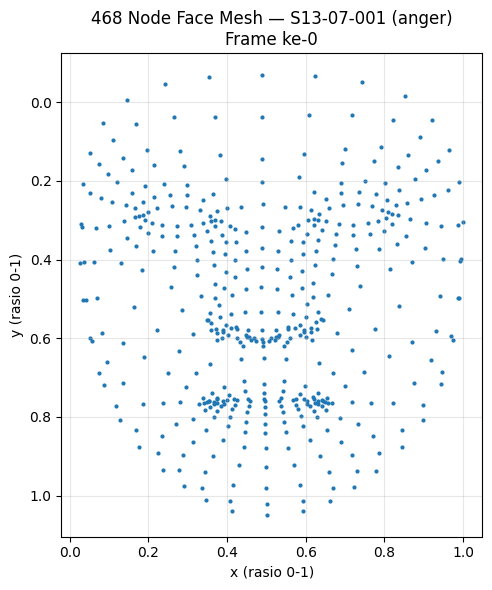

Face Mesh ditutup.
Data graf siap pre-training ST-GCN: /Users/stefanieagahari/Micro-Expression-Detector/python test/stgcn_mmew_landmarks


In [6]:
# =============================================================================
# 6. SANITY CHECK: SCATTER PLOT 468 NODE DARI FRAME PERTAMA
# =============================================================================
if ok_rows.empty:
    raise RuntimeError('Tidak ada klip yang berhasil diekstrak untuk visualisasi.')

sample = ok_rows.iloc[0]
sample_landmarks = np.load(sample['landmark_path'])

print(f"Klip contoh    : {sample['clip_id']} ({sample['emotion_label']})")
print(f"Shape tensor   : {sample_landmarks.shape}  (T={NUM_FRAMES}, V={NUM_LANDMARKS}, C={NUM_CHANNELS})")
print(f"Rentang nilai x: {sample_landmarks[..., 0].min():.3f} - {sample_landmarks[..., 0].max():.3f}")
print(f"Rentang nilai y: {sample_landmarks[..., 1].min():.3f} - {sample_landmarks[..., 1].max():.3f}")

first_frame = sample_landmarks[0]
x_coords = first_frame[:, 0]
y_coords = first_frame[:, 1]

plt.figure(figsize=(6, 6))
plt.scatter(x_coords, y_coords, s=4, c='tab:blue')
# Balik sumbu Y agar sesuai konvensi citra (asal koordinat di kiri-atas), bukan Cartesian matplotlib.
plt.gca().invert_yaxis()
# Aspek 1:1 agar geometri wajah tidak gepeng (hidung-mulut tetap proporsional).
plt.gca().set_aspect('equal')
plt.title(
    f"468 Node Face Mesh — {sample['clip_id']} ({sample['emotion_label']})\n"
    'Frame ke-0',
    fontsize=12,
)
plt.xlabel('x (rasio 0-1)')
plt.ylabel('y (rasio 0-1)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

face_mesh.close()
print('Face Mesh ditutup.')
print(f'Data graf siap pre-training ST-GCN: {OUTPUT_ROOT}')
